### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [70]:
import pandas as pd

df = pd.read_csv("prostate.data", sep="\t")

df = df.drop(df.columns[[0, -1]], axis=1)

**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

**(b)**

* **`if figsize is None: {}`**: Defines a default figure size (width and height) to ensure the grid is legible if no dimensions are provided by the user
* **`n_vars = df.shape[1]`**: Calculates the number of columns in the DataFrame : dimension of the grid
* **`fig, ax = plt.subplots(...)`**: Generates the figure and a matrix of subplots (`ax`). Each cell is a plotting area.
* **`plt.subplots_adjust(...)`**: This reduces the white space (`wspace` width and `hspace` height) between the subplots to **0.10**. This brings the plots closer together.
* **`for i in range(n_vars): for j in range(n_vars)`**: Two nested loops (`i` for rows and `j` for columns) to visit every cell in the grid:
* **`axij = ax[i][j]`**: Selects the specific subplot located at the intersection of row `i` and column `j`.
* **`axij.set_xticks([])` & `axij.set_yticks([])`**: Removes the numerical ticks from the $x$ and $y$ axes. This keeps the visualization clean, as the focus is on the **shape** of the data distribution rather than specific values.
* **`axij.margins(0.1)`**: Adds a **10%** internal margin so that data points do not touch the edges of the subplot frames.

* **`if i != j: (Scatter Plot)`**: If the row and column represent different variables, the function creates a **scatter plot**. This helps identify correlations.
* **`else: (Variable Label)`**: On the diagonal ($i = j$), plotting a variable against itself would only result in a redundant straight line. Instead, the function displays the **name of the variable** in the center of the box.
    * **`horizontalalignment / verticalalignment='center'`**: Centers the text perfectly within the box.
    * **`transform = axij.transAxes`**: This coordinate transformation ensures that `(0.5, 0.5)` refers to the geometric center of the subplot (on a 0 to 1 scale) rather than the data's raw coordinates.

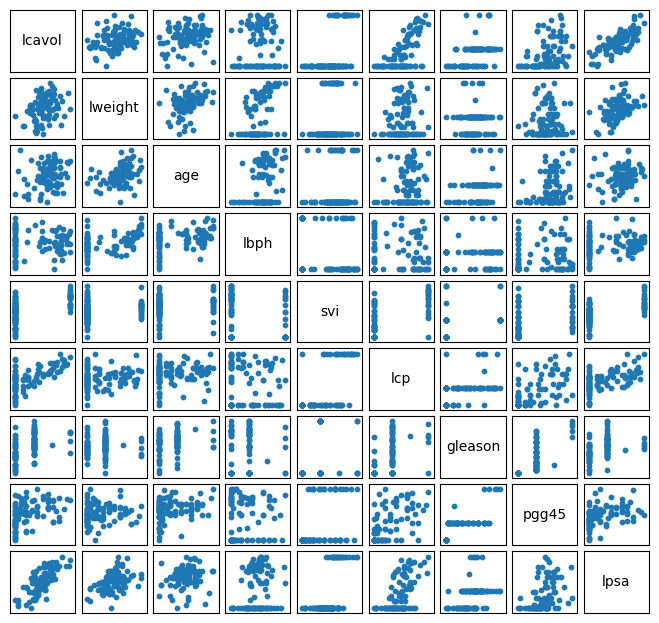

In [71]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

*<u>Correlated variables :</u>*

By observing the first row (or the first column), a point cloud that forms a clear diagonal line indicates a strong correlation.
The variables that seem the most correlated to `lcavol` are `lpsa` and `lcp`

*<u>Inferred Data Types for Predictors</u>*

| Variable | Inferred Datatype | 
| :--- | :--- |
| **`lpsa`** | **Continuous** |
| **`lweight`** | **Continuous** |
| **`age`** | **Continuous** |
| **`lbph`** | **Continuous** |
| **`svi`** | **Binary** |
| **`lcp`** | **Continuous** |
| **`gleason`** | **Ordinal (int)** |
| **`pgg45`** | **Continuous** |

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

The correlation coefficient between two vectors $x$ and $y$ $r_{xy}$ is defined as:

$$r_{xy} = \frac{cov(x,y)}{\sigma_x \sigma_y} \\
\frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

Where:
* $n$ is the sample size.
* $x_i, y_i$ are the individual sample points.
* $\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$ is the sample mean of $x$.
* $\bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$ is the sample mean of $y$

Correlation between lpsa and lcavol: 0.7345


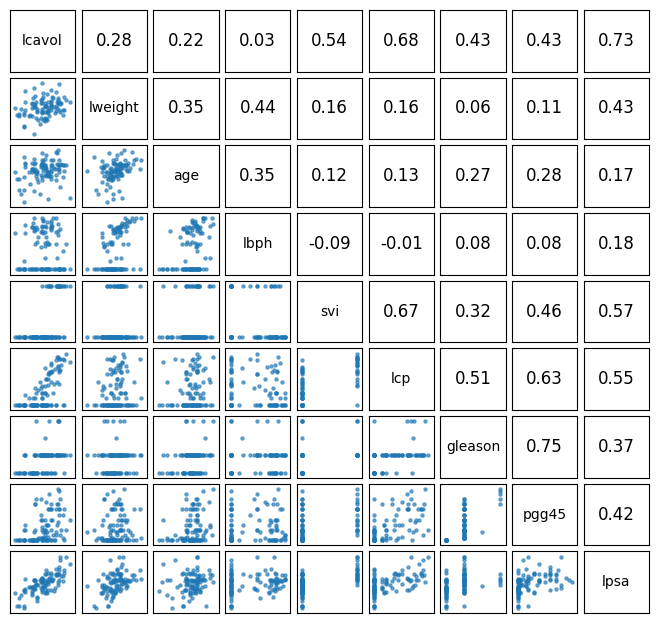

In [117]:
import numpy as np

def correlation(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
    return numerator / denominator if denominator != 0 else 0


corr_val = correlation(df['lpsa'], df['lcavol'])
print(f"Correlation between lpsa and lcavol: {corr_val:.4f}")

def pairplot_modified(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)

    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)

    plt.subplots_adjust(
        wspace=0.10, hspace=0.10,
        left=0.05, right=0.95,
        bottom=0.05, top=0.95
    )

    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]

            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)

            if i == j:
                axij.text(
                    0.5, 0.5, i_name,
                    fontsize=10,
                    ha='center',
                    va='center',
                    transform=axij.transAxes
                )

            elif i < j:
                c = df[i_name].corr(df[j_name])
                axij.text(
                    0.5, 0.5,
                    f"{c:.2f}",
                    ha='center',
                    va='center',
                    fontsize=12,
                    transform=axij.transAxes
                )

            else:
                axij.scatter(
                    df[j_name],
                    df[i_name],
                    s=5,
                    alpha=0.6
                )

    return fig, ax


fig, ax = pairplot_modified(df)
plt.show()


*Comparison with df.corr():*

df.corr() returns a correlation matrix showing correlations between all possible pairs, whereas our implementation returns a single scalar for a specific pair. By default both results should be identical.

In [118]:
pandas_corr = df.corr()
var1, var2 = 'lcavol', 'lpsa'

val_pandas = pandas_corr.loc[var1, var2]
val_manual = correlation(df[var1], df[var2])

print(f"Pandas result : {val_pandas:.10f}")
print(f"Manual result : {val_manual:.10f}")
print(f"Difference val_pandas - val_manual: {val_pandas - val_manual}")

Pandas result : 0.7344603262
Manual result : 0.7344603262
Difference val_pandas - val_manual: -1.1102230246251565e-16


The implemented correlation gives exactly the same result as df.corr(). This confirms that the formula has been correctly implemented.
The potential difference due to the $n-1$ (pandas uses n-1 to correct the bieas) correction does not affect the final correlation value because the normalization factors cancel out.

/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


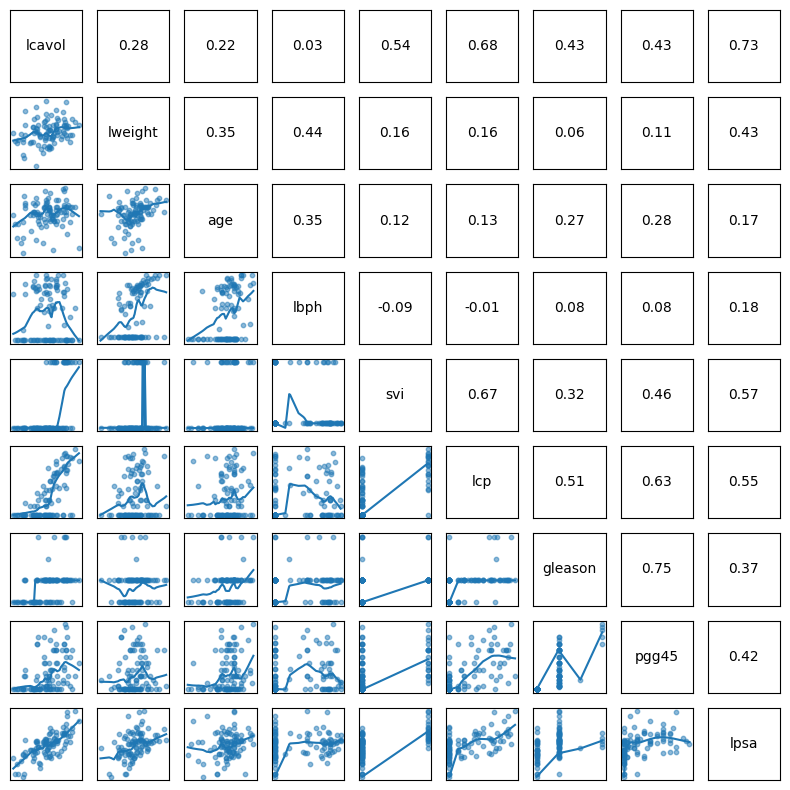

In [115]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def pairplot_with_lowess(df, figsize=(8,8)):
    n_vars = df.shape[1]
    fig, ax = plt.subplots(n_vars, n_vars, figsize=figsize)
    
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i, j]
            axij.set_xticks([])
            axij.set_yticks([])
            
            if i == j:
                axij.text(
                    0.5, 0.5,
                    df.columns[i],
                    ha='center',
                    va='center',
                    transform=axij.transAxes
                )
            
            elif i < j:
                c = df.iloc[:, i].corr(df.iloc[:, j])
                axij.text(
                    0.5, 0.5,
                    f"{c:.2f}",
                    ha='center',
                    va='center',
                    transform=axij.transAxes
                )
            
            else:
                x = df.iloc[:, j]
                y = df.iloc[:, i]
                
                axij.scatter(x, y, s=10, alpha=0.5)
                
                # LOWESS
                smoothed = lowess(y, x, frac=0.3)
                axij.plot(smoothed[:, 0], smoothed[:, 1])
    
    plt.tight_layout()
    return fig, ax

fig, ax = pairplot_with_lowess(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [74]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding? 
- Why did we add a column of ones to the dataframe?

We fixed dtype=nb.float64 so that all the variables are the of same type

The two columns svi_0 and gleason_6 are likely dropped to avoid multicollinearity. The two columns would be linearly dependent to the others (they will always add up to one) so the data would end up being collinear : problems with inversion

Adding a column of ones is done to represent the intercept in the linear regression model. In the equation of linear regression, the model includes an intercept term, and this column of ones allows the model to estimate this intercept.

In [75]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)


# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])

# add a column of ones to the dataframe
df_enc['intercept'] = 1

# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])

# get the observed values to predict
y = df['lcavol']

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.


`svi_1`:

**Coefficient: -0.2204**
This coefficient suggests that, compared to the baseline category (likely svi_0), when svi_1 (a category indicating a certain level of svi) is 1, the dependent variable (lcavol) decreases by 0.2204, holding all other variables constant.

**Standard error: 0.256**
This is the standard error for this coefficient estimate, indicating the uncertainty in the coefficient estimate.

**t-value: -0.860**
This tests the null hypothesis that the coefficient is zero (no effect). A t-value of -0.860 (|t-value| < 2) means the effect is weak.

**p-value: 0.392**
The p-value is much greater than 0.05, indicating that this coefficient is not statistically significant. This suggests that svi_1 does not have a significant relationship with lcavol at a 5% significance level.


`gleason_7`: Coefficient = 0.3117, p-value = 0.151
This suggests a positive effect of gleason_7 compared to the baseline gleason_6 (not explicitly shown, but typically the lowest category). However, the coefficient is not statistically significant (p-value > 0.05).

`gleason_8`: Coefficient = -0.7106, p-value = 0.352
This suggests a negative effect of gleason_8 compared to the baseline gleason_6. Again, this effect is not statistically significant (p-value > 0.05).

`gleason_9`: Coefficient = 0.7901, p-value = 0.109
This suggests a positive effect of gleason_9 compared to the baseline gleason_6, but once again, this coefficient is not statistically significant (p-value > 0.05).

In [76]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        22:22:14   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [77]:
results.conf_int(alpha=0.95)

,0,1
lweight,-0.024544,0.002052
age,0.024075,0.025489
lbph,-0.107860,-0.100539
lcp,0.397409,0.408110
pgg45,-0.009729,-0.009158
lpsa,0.543907,0.555239
svi_1,-0.236541,-0.204297
gleason_7,0.298138,0.325214
gleason_8,-0.758311,-0.662866
gleason_9,0.759475,0.820794


If the confidence interval contains $0$, the coefficient is not statistically significant at the $5\%$ level.

All variables except lweight are statistically significant.
lpsa and lcp appear to be the strongest predictors.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [78]:
results.pvalues

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64

From the regression output:

$t-value = 6.1$ and
$p-value < 0.001$

Because the p-value is extremely small, $p = 3 \cdot 10^{-8}$
we reject the null hypothesis : $H_0 ​: \beta_{lpsa​}=0$

Conclusion from the test

There is very strong statistical evidence that lpsa has a non-zero effect on lcavol
Since the CI entirely positive, the effect clearly present

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

Numerically, the `numpy.linalg.solve` is better because of the :
- Stability: Computing a matrix inverse can amplify rounding errors, especially if we have collinear predictors.
- Efficiency: np.linalg.solve(XtX, Xty) solves the linear system directly without explicitly inverting XtX, which is faster and more accurate.
- Condition number: Using inv can give large errors if X^TX has a high condition number (and thus it is complicated to compute the inverse matrix)

In [105]:
import numpy as np
from scipy import stats

def linear_regression_with_pvalues(X, y):
    n, p = X.shape
    
    # beta_hat = (X^T X)^(-1) X^T y

    XtX = X.T @ X
    Xty = X.T @ y
    beta_hat = np.linalg.solve(XtX, Xty)

    # Estimate the variance of the residuals
    residuals = y - X @ beta_hat
    sigma2_hat = (residuals.T @ residuals) / (n - p)
    I = np.eye(X.shape[1])
    cov_beta = sigma2_hat * np.linalg.solve(X.T @ X, I) # covariance matrix of beta_hat = sigma^2 * (X^T X)^(-1)
    se_beta = np.sqrt(np.diag(cov_beta)) # standard errors of beta_hat

    # t-statistics
    t_stats = beta_hat / se_beta 

    # two-tailed p-values
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p)) # p-value = 2 * P(T > |t|) for t-distribution with n-p degrees of freedom

    return beta_hat, p_values, t_stats, se_beta

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

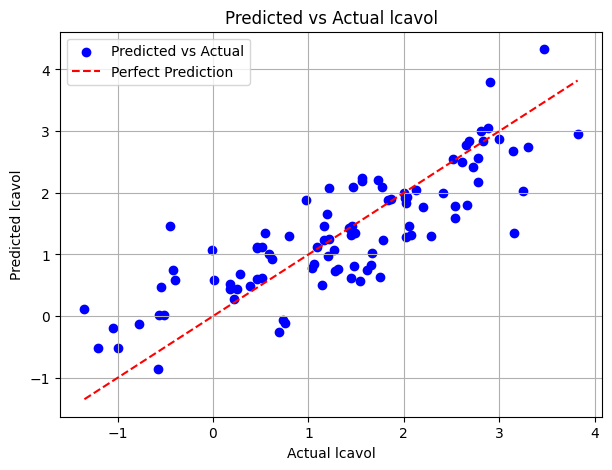

In [80]:
results.get_prediction(X).predicted_mean

y_pred = results.get_prediction(X).predicted_mean

plt.figure(figsize=(7,5))
plt.scatter(y, y_pred, color='blue') # actual vs predicted
plt.xlabel('Actual lcavol')
plt.ylabel('Predicted lcavol')
plt.title('Predicted vs Actual lcavol')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # line y=x for reference
plt.legend(['Predicted vs Actual', 'Perfect Prediction'])
plt.grid()
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).


Most points lie roughly along the red line, especially in the central portion. However, the tails (both max and min) slightly deviate from the line.

This suggests that the residuals are approximately normally distributed, but there might be mild departures in the tails.

Residual Sum of Squares (RSS): 41.814068608045346

<Figure size 700x500 with 0 Axes>

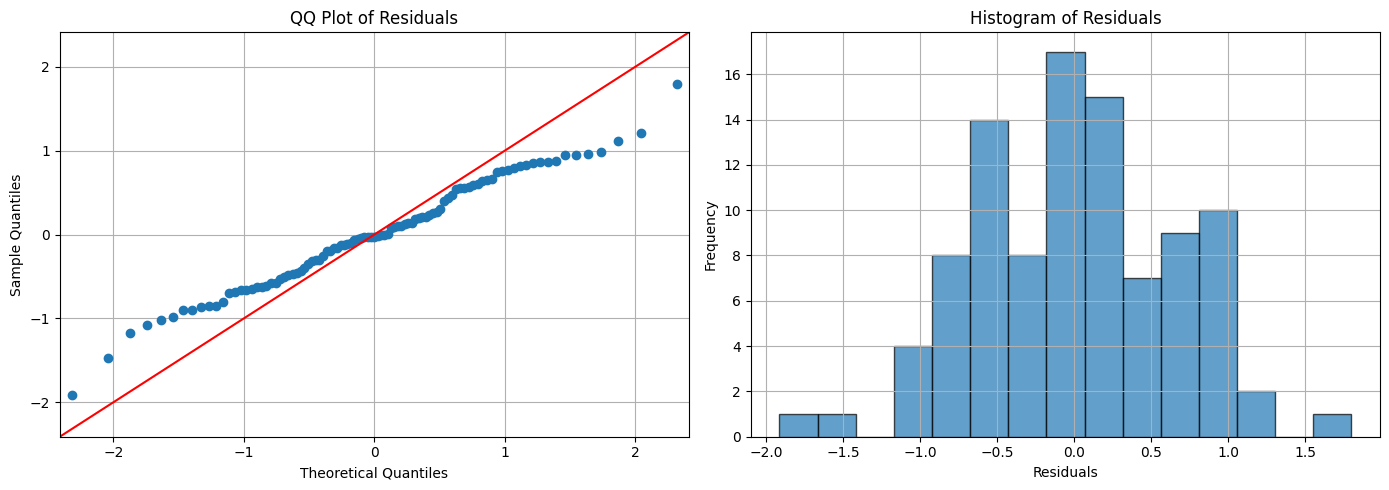

Residual Sum of Squares (RSS): 41.814068608045346


In [81]:
# Residuals
results_residuals = results.resid
plt.figure(figsize=(7,5))


# QQ plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig = sm.qqplot(results_residuals, line ='45', ax=axes[0])
axes[0].set_title('QQ Plot of Residuals')
axes[0].grid(True)


# Histogramme 
axes[1].hist(results_residuals, bins=15, edgecolor='k', alpha=0.7)
axes[1].set_title('Histogram of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)


plt.tight_layout()
plt.show()

RSS = sum(results_residuals**2)
print("Residual Sum of Squares (RSS):", RSS)

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [93]:
# new predictors without lpsa and lcp
X_new = df_enc.drop(columns=['lcp', 'lpsa', 'lcavol'])

# fit the model with the new predictors
model_new = sm.OLS(y, X_new)
results_new = model_new.fit()

results_new.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        22:30:45   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.026       0.070       1.100
age            0.0073      0.015      0.497      0.621      -0.022       0.036
lbph          -0.0746      0.077     -0.967      0.336      -0.228       0.079
pgg45         -0.0004      0.006     -0.076      0.939      -0.012       0.011
svi_1          1.0246      0.271      3.774      0.000       0.485       1.564
gleason_7      0.8007      0.274      2.918      0.004       0.255       1.346
gleason_8      0.6869      0.960      0.715      0.476      -1.221       2.595
gleason_9      1.1726      0.644      1.820      0.072      -0.108       2.453
intercept     -1.9717      1.159     -1.701      0.092      -4.275       0.332
==============================================================================
Omnibus:                        0.297   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.862   Jarque-Bera (JB):                0.473
Skew:                          -0.013   Prob(JB):                        0.789
Kurtosis:                       2.659   Cond. No.                         882.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

| Model                  | R²        | Adjusted R² |
| ---------------------- | --------- | ----------- |
| Full model             | **0.686** | 0.650       |
| Without `lpsa` & `lcp` | **0.433** | 0.381       |

Removing these two predictors reduces R² significantly.

Moreover, we notice that in the estimated coef :

| Predictor     | Full Model Coef | Full p-value | Reduced Model Coef | Reduced p-value |
| ------------- | --------------- | ------------ | ------------------ | --------------- |
| **lweight**   | -0.0112         | 0.958        | 0.5850         | 0.026       |
| **age**       | 0.0248          | 0.030        | 0.0073             | 0.621           |
| **lbph**      | -0.1042         | 0.077        | -0.0746            | 0.336           |
| **pgg45**     | -0.0094         | 0.040        | -0.0004            | 0.939           |
| **svi_1**     | -0.2204         | 0.392        | 1.0246        | 0.000       |
| **gleason_7** | 0.3117          | 0.151        | 0.8007         | 0.004       |
| **gleason_8** | -0.7106         | 0.352        | 0.6869             | 0.476           |
| **gleason_9** | 0.7901          | 0.109        | 1.1726             | 0.072           |
| **intercept** | -1.4067         | 0.111        | -1.9717            | 0.092           |


Major differences :

**lweight** changes from ~0 and not significant to strong positive and significant  
**svi_1** flips from negative and not significant as well to strongly positive and highly significant  
**gleason_7** becomes significant

Because `lpsa` and `lcp` are correlated with other predictors.  
When they are removed, their explanatory power is partially absorbed by remaining variables

**age** was significant (p = 0.03) in the full model and it becomes non-significant (p = 0.621)  
**pgg45** also loses significance



## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

a)

Best size-2 model: ('lpsa', 'lcp')
RSS: 47.27809728978648
b)

{0: [], 1: ('lpsa',), 2: ('lpsa', 'lcp'), 3: ('lpsa', 'age', 'lcp'), 4: ('lpsa', 'age', 'lbph', 'lcp'), 5: ('lpsa', 'age', 'lbph', 'lcp', 'pgg45'), 6: ('lpsa', 'age', 'lbph', 'lcp', 'gleason', 'pgg45'), 7: ('lpsa', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45'), 8: ('lpsa', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45')}


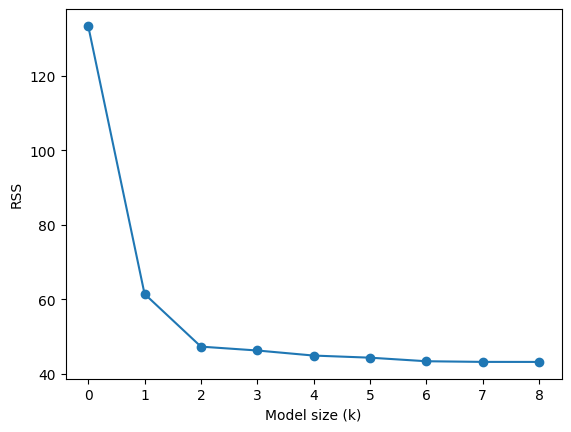

c)



In [94]:
### (a) Best model of size k = 2
import itertools
import statsmodels.api as sm
import numpy as np

predictors = ['lpsa','lweight','age','lbph','svi','lcp','gleason','pgg45']

best_rss = np.inf
best_model = None

for combo in itertools.combinations(predictors, 2):
    X_k = df[list(combo)]
    X_k = sm.add_constant(X_k)
    
    model = sm.OLS(df['lcavol'], X_k).fit()
    
    if model.ssr < best_rss:
        best_rss = model.ssr
        best_model = combo
print("a)\n")
print("Best size-2 model:", best_model)
print("RSS:", best_rss)
print("b)\n")

### (b) Best model for each k
best_models = {}
rss_values = []

for k in range(0, 9):
    best_rss = np.inf
    best_combo = None
    
    if k == 0:
        X_k = np.ones((len(df),1))
        model = sm.OLS(df['lcavol'], X_k).fit()
        best_rss = model.ssr
        best_combo = []
    else:
        for combo in itertools.combinations(predictors, k):
            X_k = sm.add_constant(df[list(combo)])
            model = sm.OLS(df['lcavol'], X_k).fit()
            
            if model.ssr < best_rss:
                best_rss = model.ssr
                best_combo = combo
                
    best_models[k] = best_combo
    rss_values.append(best_rss)

print(best_models)
### plot results for each k
import matplotlib.pyplot as plt

plt.plot(range(9), rss_values, marker='o')
plt.xlabel("Model size (k)")
plt.ylabel("RSS")
plt.show()

### (c) Conclusion
print("c)\n")



Minimizing the RSS alone is not a good strategy for selecting the optimal model size.

Indeed:

- The RSS always decreases when additional variables are included in the model.
- This systematically favors more complex models.
- It may lead to overfitting.

Therefore, the RSS alone does not allow us to determine the optimal model size.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

**Solution:**

**(a)** Split-validation consists of splitting the dataset randomly into two disjoint parts: a training set and a validation set. The modal is trained on the training set and then evaluated on the validation set, which has not been used during the fitting process.

By using this method, we get to see how our modal perfoms on testing data, so we get an estimate of the test error which we are interested in, unlike minimizing the Training Error on the full datasetas in the item (c) of the previous Exercice. 

This method helps detect overfitting and gives a more realistic measure of the generalization performance of the model.

**(b)**

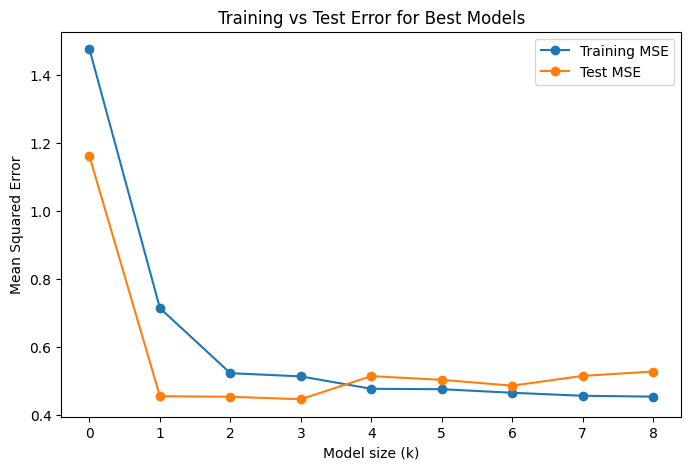

In [97]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

predictors = ['lpsa','lweight','age','lbph','svi','lcp','gleason','pgg45']

X = df[predictors]
y = df['lcavol']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

train_errors = []
test_errors = []

#Loop for each best best model for sizes 0 to 8
for k in range(9):
    
    selected = best_models[k]

    if k == 0 or len(selected) == 0:
        X_train_k = np.ones((len(X_train), 1))
        X_test_k = np.ones((len(X_test), 1))
    else:
        X_train_k = sm.add_constant(X_train[list(selected)])
        X_test_k = sm.add_constant(X_test[list(selected)])

    model = sm.OLS(y_train, X_train_k).fit()

    #Predictions
    y_train_pred = model.predict(X_train_k)
    y_test_pred = model.predict(X_test_k)

    #MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    #Store errors
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot training and test error vs model size
plt.figure(figsize=(8,5))
plt.plot(range(9), train_errors, marker='o', label='Training MSE')
plt.plot(range(9), test_errors, marker='o', label='Test MSE')
plt.xlabel('Model size (k)')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Test Error for Best Models')
plt.legend()
plt.show()

**(c)** Based on the previous results, the best model for this dataset is the best model of size k = 3 since it has the lowest prediction mean squared error among all the considered models.

Although the training error continues to decrease as the model size increases, the test error reaches its minimum at k = 3 then starts increasing. This indicates that adding more predictors beyond this point may lead to overfitting and does not improve predictive performance.

Below are the parameter estimates for the model trained on the whole dataset:

In [98]:
import statsmodels.api as sm

# Best model of size k = 3
selected = best_models[3]   # ('lpsa', 'age', 'lcp')

# Build design matrix using the whole dataset
X_k = sm.add_constant(df[list(selected)])
y = df['lcavol']

# Fit model on entire dataset
model_full = sm.OLS(y, X_k).fit()

# Print full summary
print(model_full.summary())

# Print only coefficients
print("\nEstimated coefficients:")
print(model_full.params)

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     58.41
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.56e-21
Time:                        10:55:48   Log-Likelihood:                -101.70
No. Observations:                  97   AIC:                             211.4
Df Residuals:                      93   BIC:                             221.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7839      0.639     -1.228      0.2

**(d)** The main limitation of split-validation is: instability due to using only one split. In fact, the results depend ont the random split of the dataset and they may change if we run it again with a different split. This makes the selection of the best model somwhat arbitrary.

We can illustrate this by running split-validation multiple times with different **random-state** values and observe how the best model changes.

To adress this problem we can use **K-Fold Cross-Validation**, coded below:

Model size 1: 5-Fold CV MSE = 0.6532
Model size 2: 5-Fold CV MSE = 0.5285
Model size 3: 5-Fold CV MSE = 0.5250
Model size 4: 5-Fold CV MSE = 0.5231
Model size 5: 5-Fold CV MSE = 0.5355
Model size 6: 5-Fold CV MSE = 0.5377
Model size 7: 5-Fold CV MSE = 0.5660
Model size 8: 5-Fold CV MSE = 0.5871


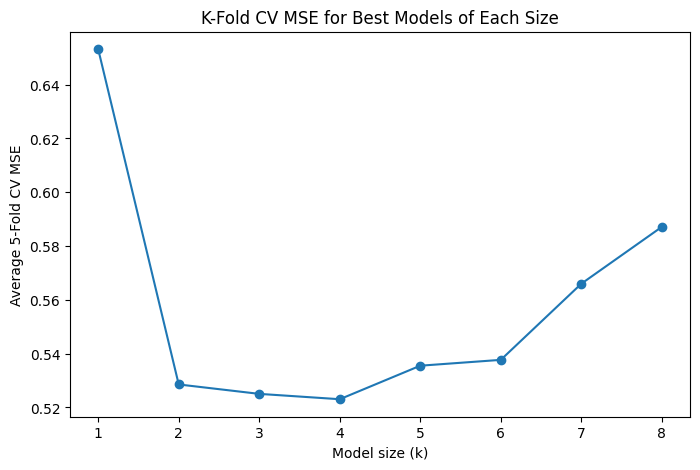

In [99]:
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare predictors and response
predictors = ['lpsa','lweight','age','lbph','svi','lcp','gleason','pgg45']
X = df[predictors].values
y = df['lcavol'].values

kf = KFold(n_splits=5, shuffle=True, random_state=1)

cv_mse_per_model = []

# Loop over model sizes k = 1..8
for k in range(1, 9):
    selected = best_models[k]  # best predictors for this size
    fold_mse = []

    for train_index, test_index in kf.split(X):
        if len(selected) == 0:
            # Model with no predictors: just intercept
            X_train_k = np.ones((len(train_index), 1))
            X_test_k = np.ones((len(test_index), 1))
        else:
            X_train_k = sm.add_constant(X[train_index][:, [predictors.index(p) for p in selected]])
            X_test_k = sm.add_constant(X[test_index][:, [predictors.index(p) for p in selected]])

        y_train_k = y[train_index]
        y_test_k = y[test_index]

        model = sm.OLS(y_train_k, X_train_k).fit()
        y_pred = model.predict(X_test_k)
        fold_mse.append(mean_squared_error(y_test_k, y_pred))

    avg_mse = np.mean(fold_mse)
    cv_mse_per_model.append(avg_mse)
    print(f"Model size {k}: 5-Fold CV MSE = {avg_mse:.4f}")

# Plot CV MSE vs model size
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,9), cv_mse_per_model, marker='o')
plt.xlabel("Model size (k)")
plt.ylabel("Average 5-Fold CV MSE")
plt.title("K-Fold CV MSE for Best Models of Each Size")
plt.show()

**Comments:**

- The plot of K-Fold CV MSE vs. model size shows that the CV error decreases initially (from model size 1 to 4), reaches a minimum at size 4, and then starts increasing for larger models.

- This confirms that using K-Fold Cross-Validation stabilizes the model selection process. Instead of relying on a single split, it averages the prediction error over multiple folds, giving a more robust estimate of model performance.

- The increase in MSE for model sizes larger than 4 also highlights overfitting: adding too many predictors increases complexity without improving predictive accuracy.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

The best model to predict lcavol is the size-4 model. This model balances prediction accuracy and model complexity. Using K-Fold Cross-Validation ensures that this choice is stable and not dependent on a single random train/test split.